# Part 4: Data Visualization & Machine Learning

## Theme: Student Performance Analysis & Prediction

## Task 1 — Data Exploration with Pandas

In [3]:
import pandas as pd

In [4]:
# Loading the dataset

df = pd.read_csv("students.csv")

In [5]:
# Printing the first 5 rows

print("First 5 rows:")
print(df.head())

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [6]:
print(df.columns)

Index(['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct',
       'study_hours_per_day', 'passed'],
      dtype='object')


In [7]:
# Printing the shape (rows × columns) and the data type of each column

print("\nShape of dataset:")
rows, columns = df.shape
print("Rows:", rows)
print("Columns:", columns)

print("\nData types of each column:")
print(df.dtypes)


Shape of dataset:
Rows: 15
Columns: 9

Data types of each column:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [8]:
# Printing summary statistics (mean, min, max, std) for all numeric columns

print("\nSummary statistics:")
print(df.describe())


Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               

In [9]:
# Printing the count of students who passed and who failed

print("\nPass/Fail count:")
pass_fail_count = df['passed'].value_counts()
print(pass_fail_count)


Pass/Fail count:
1    9
0    6
Name: passed, dtype: int64


In [10]:
# Computing and printing the average score per subject separately for passing and failing students.

# List of subjects
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Students who passed
passed_students = df[df['passed'] == 1]
print("\nAverage scores for PASSED students:")
print(passed_students[subject_cols].mean())

# Students who failed
failed_students = df[df['passed'] == 0]
print("\nAverage scores for FAILED students:")
print(failed_students[subject_cols].mean())


Average scores for PASSED students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores for FAILED students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [11]:
# Finding and printing the student with the highest overall average across all 5 subjects

# Creating a new column for average score
df["avg_score"] = df[subject_cols].mean(axis=1)

# Finding the index of highest average and getting the students details
highest_index = df["avg_score"].idxmax()
topper = df.loc[highest_index]

print("\nTop student:")
print("Name:", topper["name"])
print("Average Score:", topper["avg_score"])


Top student:
Name: Diana
Average Score: 94.0


## Task 2 — Data Visualization with Matplotlib 

In [12]:
import matplotlib.pyplot as plt

Bar Chart — Average Score per Subject -- Bar Chart — Average score per subject across all students (one bar per subject, x-axis = subject name, y-axis = average score). Save plot as a .png file

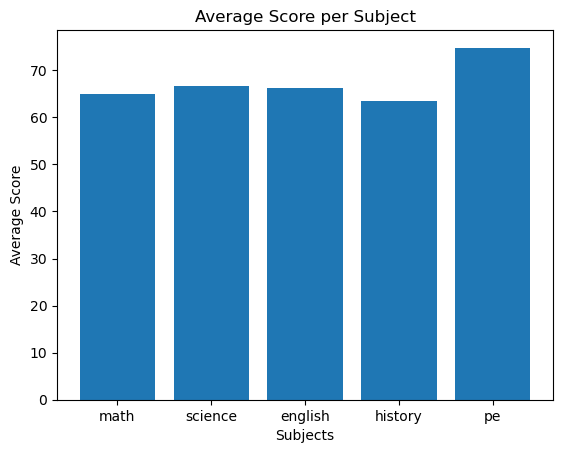

In [13]:
# Calculate average per subject
avg_scores = df[subject_cols].mean()

# Plotting bar graph
plt.figure()
plt.bar(subject_cols, avg_scores)

# Giving Labels and title
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

# Saving in png and displaying
plt.savefig("plot1_bar.png")
plt.show()

In [ ]:
Histogram — Distribution of math scores. Use 5 bins. Add a vertical dashed line at the mean math score and label it.

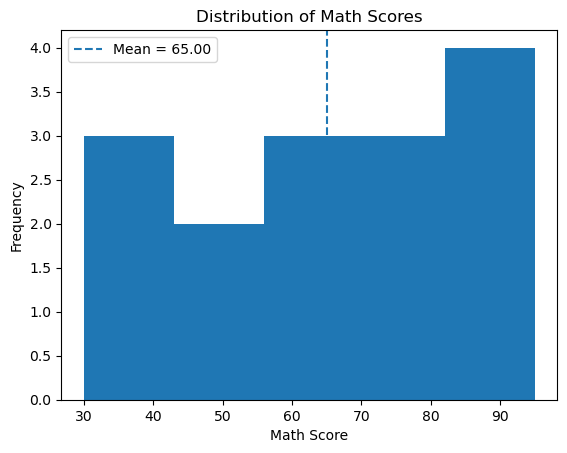

In [14]:
# Get math scores
math_scores = df['math']

# Plotting histogram
plt.figure()
plt.hist(math_scores, bins=5)

# Mean line
mean_math = math_scores.mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

# Giving Labels and title
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.legend()

# Saving in png and displaying
plt.savefig("plot2_histogram.png")
plt.show()

In [ ]:
# Scatter Plot — study_hours_per_day (x-axis) vs avg_score (y-axis). Colour each point differently based on passed:
# one colour for Pass, another for Fail. Include a legend.

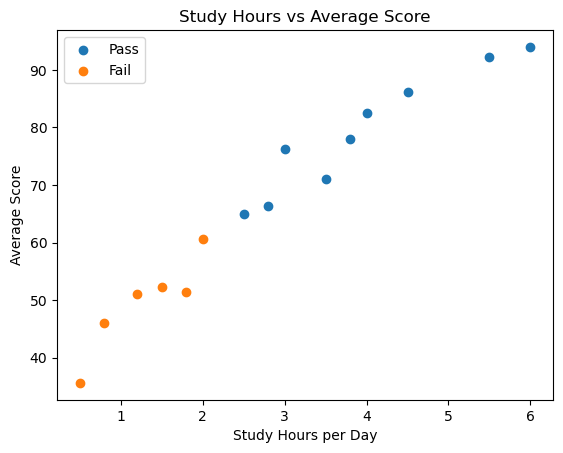

In [15]:
# Separating data
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]

# Plotting a scatter plot
plt.figure()

plt.scatter(passed['study_hours_per_day'], passed['avg_score'], label="Pass")
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], label="Fail")

# Giving Labels and title
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend()

# Saving in png and displaying
plt.savefig("plot3_scatter.png")
plt.show()

In [ ]:
# Box Plot — Show the distribution of attendance_pct for passing students vs failing students side by side.

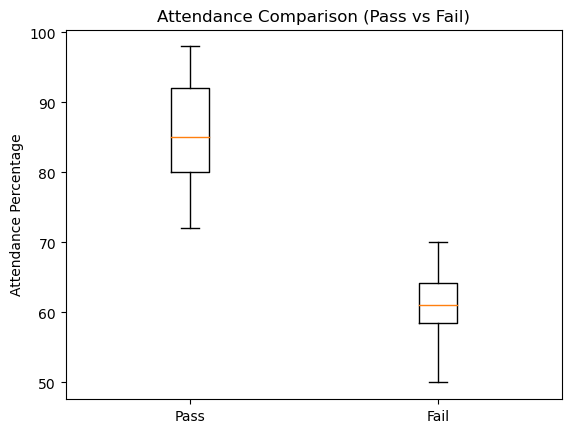

In [16]:
# Getting the attendance lists
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

# Plotting a box plot
plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])

# Giving Labels and title
plt.title("Attendance Comparison (Pass vs Fail)")
plt.ylabel("Attendance Percentage")

# Saving in png and displaying
plt.savefig("plot4_boxplot.png")
plt.show()

In [ ]:
# Line Plot — Plot the math score and science score for every student. X-axis = student name, Y-axis = score. 
# Use different line styles or markers for each subject.

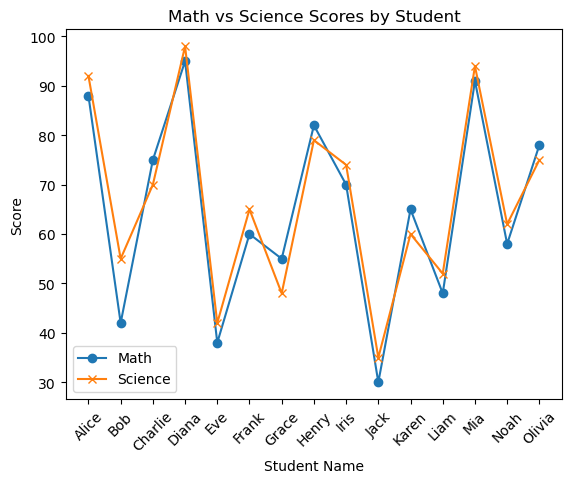

In [17]:
# X-axis (student names)
names = df['name']

# Plotting the line plot
plt.figure()

plt.plot(names, df['math'], marker='o', label="Math")
plt.plot(names, df['science'], marker='x', label="Science")

# Giving Labels and title
plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)  # to prevent overlapping of names written on X axis
plt.legend()

# Saving in png and displaying
plt.savefig("plot5_line.png")
plt.show()

## Task 3 — Data Visualization with Seaborn 

In [18]:
import seaborn as sns

In [ ]:
# Creating a Seaborn bar plot showing the average math score and average science score, split by passed (Pass vs Fail).

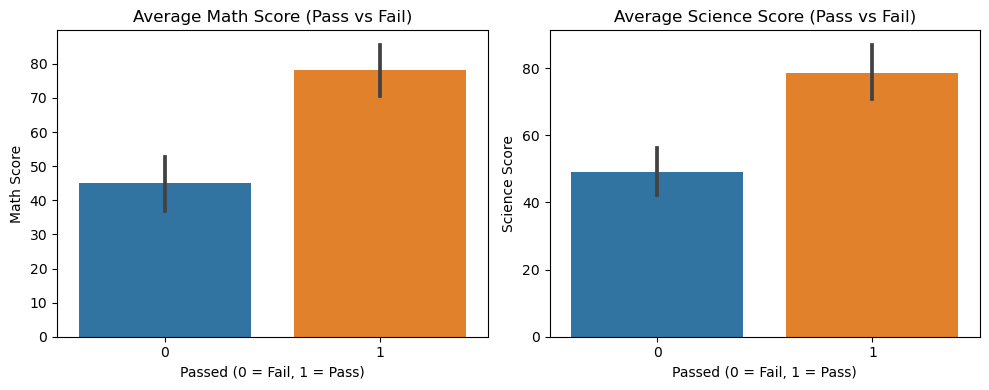

In [19]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plotting the bar chart for Math plot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# Plotting the bar chart for Science plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

# Saving in png and displaying
plt.tight_layout()
plt.savefig("seaborn_barplots.png")
plt.show()

In [20]:
print("Math averages:")
print(df.groupby("passed")["math"].mean())

print("\nScience averages:")
print(df.groupby("passed")["science"].mean())

Math averages:
passed
0    45.166667
1    78.222222
Name: math, dtype: float64

Science averages:
passed
0    49.000000
1    78.555556
Name: science, dtype: float64


In [ ]:
# Creating a Seaborn scatter plot of attendance_pct (x-axis) vs avg_score (y-axis), coloured by passed.
# Adding a regression line using sns.regplot() for each group (Pass and Fail) on the same axes.

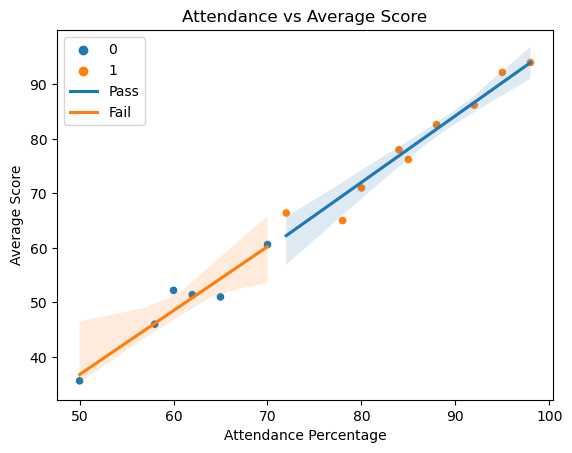

In [21]:
plt.figure()

# Scatter plot (colored by passed)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

# Giving Labels and title
plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")

plt.legend()

# Saving in png and displaying
plt.savefig("seaborn_scatter.png")
plt.show()

In [ ]:
# Seaborn was easier to use for these plots because it automatically handles grouping
# and gives better-looking visuals with less code. In Matplotlib, we had to manually
# separate data and manage styling, while Seaborn simplified this with built-in functions.

## Task 4 — Machine Learning with scikit-learn

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Step 1 — Preparing Data:

In [23]:
# Features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]   # only features
y = df['passed']       # target

In [24]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# Step 2 — Training the Model:

In [25]:
# Creating model
model = LogisticRegression()

# Training the model
model.fit(X_train_scaled, y_train)

# Training accuracy and printing
train_preds = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_preds)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [ ]:
# Step 3 — Evaluating the Model:

In [26]:
# Predicting on test set
y_pred = model.predict(X_test_scaled)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", test_accuracy)

# Show each student's result
print("\nTest Set Predictions:")

test_names = df.loc[X_test.index, 'name']

for i in range(len(X_test)):
    name = test_names.iloc[i]
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    
    if actual == predicted:
        result = "✅ Correct"
    else:
        result = "❌ Wrong"
    
print("Name:", name)
print("Actual:", actual)
print("Predicted:", predicted)
print("Result:", result)
print("-------------------")


Test Accuracy: 1.0

Test Set Predictions:
Name: Alice
Actual: 1
Predicted: 1
Result: ✅ Correct
-------------------


In [ ]:
# Step 4 — Feature Importance:

In [27]:
# Extracting the model coefficients
coefficients = model.coef_[0]

# Pairing each coefficient with its feature name
feature_importance = list(zip(feature_cols, coefficients))

# sorting by absolute value (largest first) and printing them
def get_abs_value(item):
    return abs(item[1])

feature_importance.sort(key=get_abs_value, reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")


Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


In [ ]:
# Creating a horizontal bar chart using Matplotlib showing all feature coefficients. 
# Using different colours for positive (green) and negative (red) coefficients. Adding a title and axis labels.
# A positive coefficient means that feature pushes the prediction towards Pass; a negative one pushes towards Fail.

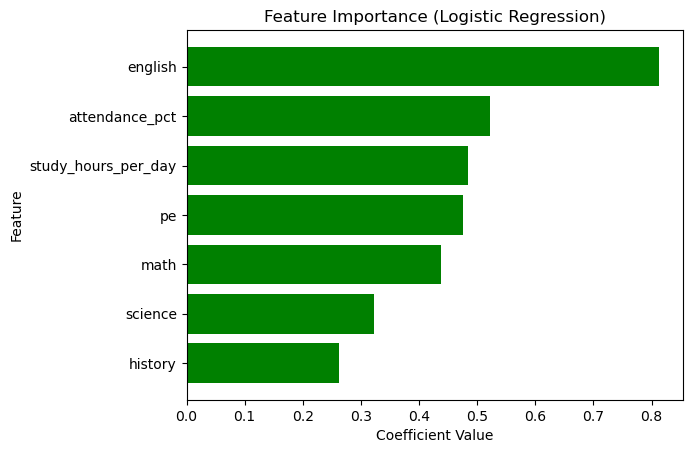

In [28]:
# Separating names and values
features = [item[0] for item in feature_importance]
values = [item[1] for item in feature_importance]

# Assigning colors
colors = []
for v in values:
    if v >= 0:
        colors.append('green')
    else:
        colors.append('red')

# Plotting the horizontal bar chart
plt.figure()
plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.gca().invert_yaxis()  # highest at top

plt.savefig("feature_importance.png")
plt.show()

In [ ]:
# Step 5 — Prediction for a New Student 

In [29]:
# New student data (same order as feature_cols)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

# Output
if prediction == 1:
    print("\nNew Student Prediction: PASS")
else:
    print("\nNew Student Prediction: FAIL")

print("Probability [Fail, Pass]:", probability)


New Student Prediction: PASS
Probability [Fail, Pass]: [0.09203526 0.90796474]


C:\Users\Amit D\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
